<a href="https://colab.research.google.com/github/tuli-pen/machine_learning_101/blob/master/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine paso a paso, haremos la optimización usando optimización convexa

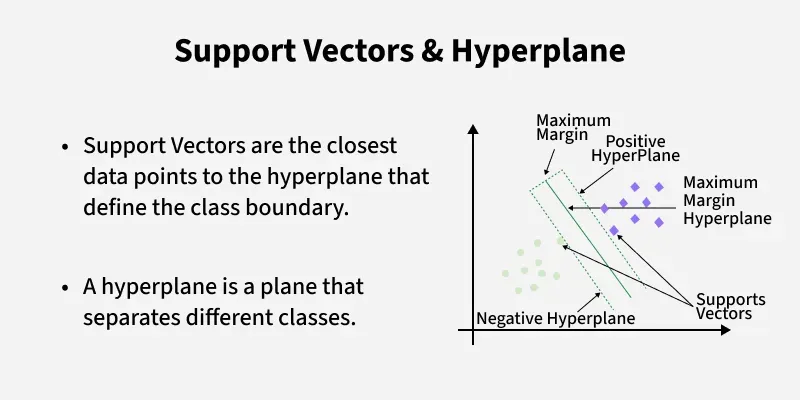

El objetivo de una SVM es encontrar un hiperplano que separe (de ser posible xd) dos clases de datos, maximizando el "margen" o la distancia entre el hiperplano y los puntos más cercanos de cada clase (esos son los que vamos a llamar los **vectores de soporte**).

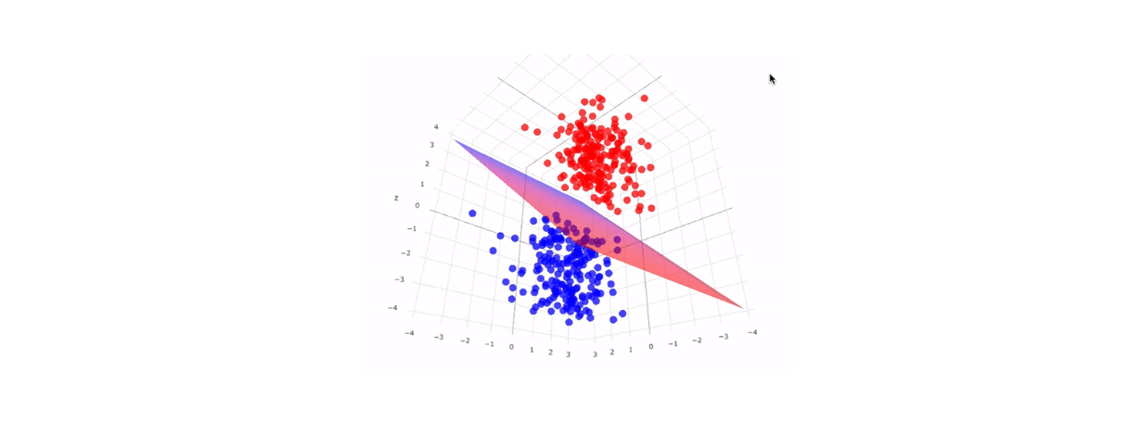

## El problema principal

Supongamos que tenemos un conjunto de datos linealmente separable. Queremos encontrar los weights $w$ y el bias $b$ de la ecuación del hiperplano:
$$w^T x + b = 0$$

La clase de una predicción se define por el signo de $w^T x + b$. Queremos que para nuestros datos de entrenamiento $(x_i, y_i)$, donde $y_i \in \{-1, 1\}$ se cumpla:
$$y_i (w^T x_i + b) \ge 1$$

El ancho del margen entre las dos clases es $\frac{2}{||w||}$. Para maximizar ese margen, necesitamos minimizar $||w||$. Matemáticamente, por conveniencia para las derivadas, esto se formula como un problema de optimización convexa:

**Minimizar:**
$$\frac{1}{2} ||w||^2$$
Sujeto a:
$$y_i (w^T x_i + b) - 1 \ge 0 \quad \text{para todo } i$$

### El Lagrangiano y la dualidad de Wolfe

En optimización convexa, el paso del problema original (Primal) a su formulación equivalente (Dual) es una técnica fundamental para resolver problemas con restricciones de manera eficiente.

#### *El operador Lagrangiano*
El problema primal de la SVM consiste en minimizar una función objetivo sujeta a restricciones de desigualdad lineales. Para resolverlo, se define la **función Lagrangiana** ($\mathcal{L}$), la cual incorpora las restricciones directamente en el objetivo mediante la introducción de un vector de variables duales $\alpha \in \mathbb{R}^n$ (denominados *Multiplicadores de Lagrange*):

$$\mathcal{L}(w, b, \alpha) = \frac{1}{2} \|w\|^2 - \sum_{i=1}^{n} \alpha_i \Big[ y_i (w^T x_i + b) - 1 \Big]$$

Donde se impone la restricción de no negatividad $\alpha_i \ge 0$. El Lagrangiano actúa penalizando algebraicamente cualquier violación de las restricciones de soporte.

#### *El droblema dual de Wolfe*
Bajo condiciones de convexidad y cumplimiento de las condiciones de regularidad (como la condición de Slater), se garantiza la **Dualidad fuerte**. Esto significa que el valor óptimo del problema primal coincide exactamente con el valor óptimo del problema dual.

Para construir el problema Dual de Wolfe, se explota la condición de estacionariedad imponiendo que el gradiente del Lagrangiano respecto a las variables primales ($w$ y $b$) sea igual a cero:

$$\nabla_w \mathcal{L} = 0 \implies w = \sum_{i=1}^{n} \alpha_i y_i x_i$$
$$\frac{\partial \mathcal{L}}{\partial b} = 0 \implies \sum_{i=1}^{n} \alpha_i y_i = 0$$

Al sustituir estas condiciones de optimalidad analítica de vuelta en la función del Lagrangiano, se elimina la dependencia de $w$ y $b$, dando lugar al **problema Dual**, el cual depende exclusivamente de los multiplicadores $\alpha$.

## Ahora sí, planteemos el problema Dual

Resolver el problema primal directamente es difícil debido a las restricciones. Usemos los **Multiplicadores de Lagrange** ($\alpha_i \ge 0$) para llevar las restricciones a la función objetivo.

El Lagrangiano es:
$$L(w, b, \alpha) = \frac{1}{2} ||w||^2 - \sum_{i=1}^{n} \alpha_i [y_i (w^T x_i + b) - 1]$$

Para encontrar el mínimo respecto a $w$ y $b$, derivamos e igualamos a cero:
1. $\frac{\partial L}{\partial w} = w - \sum_{i=1}^{n} \alpha_i y_i x_i = 0 \implies w = \sum_{i=1}^{n} \alpha_i y_i x_i$
2. $\frac{\partial L}{\partial b} = -\sum_{i=1}^{n} \alpha_i y_i = 0 \implies \sum_{i=1}^{n} \alpha_i y_i = 0$

Sustituyendo esto de vuelta en $L$, obtenemos el **Problema Dual**, que depende únicamente de $\alpha$:

**Maximizar:**
$$W(\alpha) = \sum_{i=1}^{n} \alpha_i - \frac{1}{2} \sum_{i=1}^{n} \sum_{j=1}^{n} \alpha_i \alpha_j y_i y_j (x_i^T x_j)$$
Sujeto a:
$$\alpha_i \ge 0$$
$$\sum_{i=1}^{n} \alpha_i y_i = 0$$

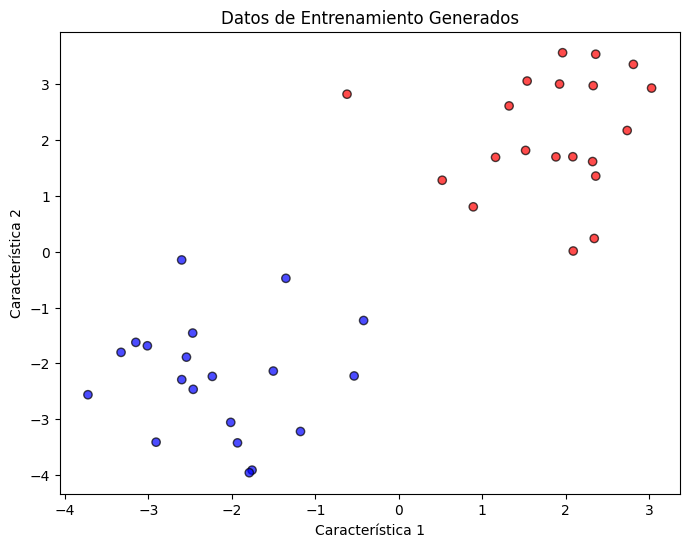

In [1]:
# Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import cvxopt

# Hacemos que la salida de cvxopt sea silenciosa para no saturar la pantalla
cvxopt.solvers.options['show_progress'] = False

# Generamos datos de juguete linealmente separables
np.random.seed(42)
# Clase -1 (puntos en la esquina inferior izquierda)
X1 = np.random.randn(20, 2) - [2, 2]
y1 = np.ones(20) * -1

# Clase 1 (puntos en la esquina superior derecha)
X2 = np.random.randn(20, 2) + [2, 2]
y2 = np.ones(20)

# Unimos los datos
X = np.vstack((X1, X2))
y = np.hstack((y1, y2))

# Visualizamos los datos iniciales
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolors='k')
plt.title("Datos de Entrenamiento Generados")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.show()

## Programación Cuadrática (QP)

Vamos a usar la librería `cvxopt`. Su solver genérico minimiza problemas de la siguiente forma matemática estándar:

**Minimizar:**
$$\frac{1}{2} x^T P x + q^T x$$
Sujeto a:
$$G x \le h$$
$$A x = b$$

Para usar esta librería, debemos "mapear" nuestro problema Dual a estas matrices. En nuestro caso, el vector a optimizar es $\alpha$ (entonces $x = \alpha$).

1. Como queremos **Maximizar** el dual, invertimos el signo para **Minimizar**:
   $$\text{Minimizar: } \frac{1}{2} \sum \sum \alpha_i \alpha_j y_i y_j (x_i^T x_j) - \sum \alpha_i$$
2. **Matriz $P$**: Representa la parte cuadrática. $P_{i,j} = y_i y_j (x_i^T x_j)$.
3. **Vector $q$**: Representa la parte lineal. Como tenemos $-\sum \alpha_i$, el vector $q$ es un vector de $-1$s.
4. **Matriz $G$ y vector $h$**: Para la restricción $\alpha_i \ge 0$, que es $-\alpha_i \le 0$. Por lo tanto, $G$ es una matriz identidad negativa ($-I$) y $h$ es un vector de ceros.
5. **Matriz $A$ y vector $b$**: Para la restricción $\sum \alpha_i y_i = 0$. $A$ es el vector de etiquetas $y^T$ y $b$ es un escalar igual a cero.

In [3]:
# Obtenemos el número de muestras
n_samples, n_features = X.shape

# Calculamos la matriz P (y_i * y_j * (x_i dot x_j))
# Podemos usar np.outer(y, y) para multiplicar las etiquetas y np.dot(X, X.T) para el producto punto
K = np.dot(X, X.T)
P = cvxopt.matrix(np.outer(y, y) * K)

# Calculamos el vector q (vector de -1s)
q = cvxopt.matrix(np.ones(n_samples) * -1)

# Calculamos la matriz G y h (-alpha <= 0)
G = cvxopt.matrix(np.diag(np.ones(n_samples) * -1))
h = cvxopt.matrix(np.zeros(n_samples))

# Calculamos la matriz A y b (y^T alpha = 0)
A = cvxopt.matrix(y, (1, n_samples))
b = cvxopt.matrix(0.0)

# Resolvemos usando cvxopt
solucion = cvxopt.solvers.qp(P, q, G, h, A, b)

# Extraemos los valores de alpha
alphas = np.ravel(solucion['x'])

## Obteniendo los weights ($w$), el bias ($b$) y los *vectores de soporte*

Los multiplicadores de Lagrange ($\alpha$) serán cero para los puntos que están lejos de la frontera. Serán mayores a cero solo para los vectores de soporte (los puntos que están exactamente sobre el margen).

Una vez que tenemos $\alpha$, calculamos $w$ usando nuestra ecuación derivada anteriormente:
$$w = \sum_{i=1}^{n} \alpha_i y_i x_i$$

Para el sesgo $b$, sabemos que para cualquier vector de soporte $x_s$:
$$y_s (w^T x_s + b) = 1 \implies b = y_s - w^T x_s$$
Por estabilidad numérica, calcularemos esto para todos los vectores de soporte y sacaremos el promedio.

Número de vectores de soporte encontrados: 3
Vector de pesos w: [0.52288304 0.64462865]
Sesgo b: 0.01456939815814214


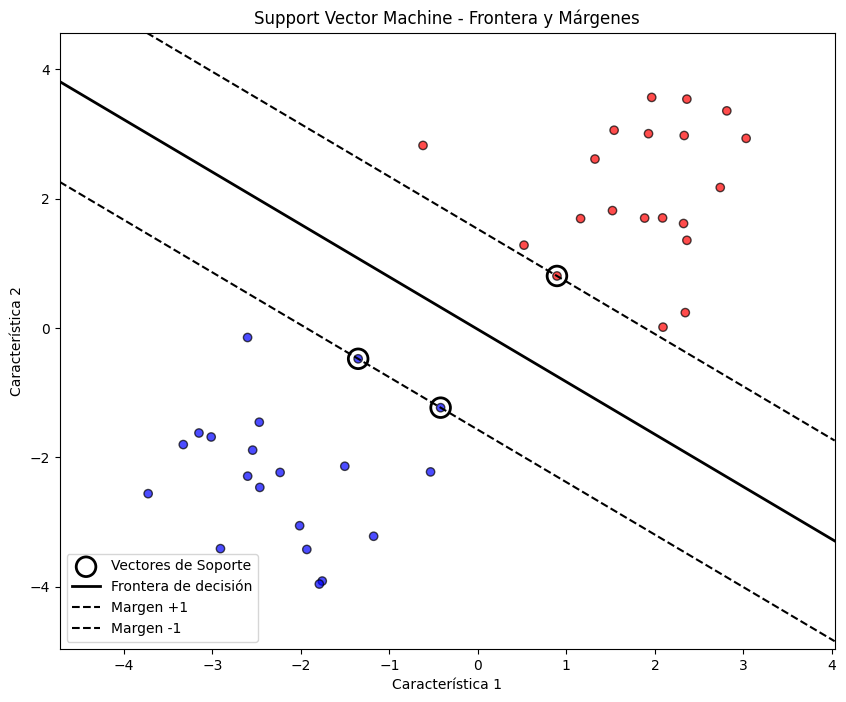

In [4]:
# Los vectores de soporte tienen un alpha mayor a 0 (usamos un umbral pequeño por precisión de coma flotante)
umbral = 1e-5
sv_index = alphas > umbral
alphas_sv = alphas[sv_index]
sv = X[sv_index]
sv_y = y[sv_index]

print(f"Número de vectores de soporte encontrados: {len(alphas_sv)}")

# 1. Calculamos w: w = sum(alpha_i * y_i * x_i)
w = np.zeros(n_features)
for i in range(len(alphas_sv)):
    w += alphas_sv[i] * sv_y[i] * sv[i]

print(f"Vector de pesos w: {w}")

# 2. Calculamos b: b = y_s - w * x_s (Promedio sobre los vectores de soporte)
b = 0
for i in range(len(alphas_sv)):
    b += sv_y[i] - np.dot(w, sv[i])
b = b / len(alphas_sv)

print(f"Sesgo b: {b}")

# 3. Función para dibujar la línea de decisión y los márgenes
def graficar_frontera(X, y, w, b, sv):
    plt.figure(figsize=(10, 8))

    # Graficar los puntos
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', alpha=0.7, edgecolors='k')

    # Resaltar los vectores de soporte
    plt.scatter(sv[:, 0], sv[:, 1], s=200, facecolors='none', edgecolors='k', linewidth=2, label="Vectores de Soporte")

    # Crear un grid para las líneas
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_puntos = np.linspace(x_min, x_max, 100)

    # w0*x0 + w1*x1 + b = 0 => x1 = (-w0/w1)*x0 - b/w1
    y_puntos = (-w[0] / w[1]) * x_puntos - (b / w[1])

    # Márgenes: w0*x0 + w1*x1 + b = 1 y -1
    margen_arriba = (-w[0] / w[1]) * x_puntos - ((b - 1) / w[1])
    margen_abajo = (-w[0] / w[1]) * x_puntos - ((b + 1) / w[1])

    # Graficar líneas
    plt.plot(x_puntos, y_puntos, 'k-', linewidth=2, label='Frontera de decisión')
    plt.plot(x_puntos, margen_arriba, 'k--', label='Margen +1')
    plt.plot(x_puntos, margen_abajo, 'k--', label='Margen -1')

    plt.title("Support Vector Machine - Frontera y Márgenes")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.legend()
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.show()

graficar_frontera(X, y, w, b, sv)

### Eso es todo yeeii 🌷